# CPDS-AI: Audio Classification (Multi-Dataset Training)

This notebook trains a lightweight AudioCNN to classify **baby cry vs environmental noise** by merging multiple cry datasets for maximum generalization.

### Data Sources
| # | Dataset | Source | Approx. Files |
|---|---------|--------|---------------|
| 1 | Baby Crying Sounds (Menna Ahmed) | Kaggle | ~1313 |
| 2 | Donate-a-cry Corpus | GitHub | ~1585 |
| 3 | ESC-50 `crying_baby` class | GitHub | 40 |
| 4 | ESC-50 (vehicle/environment noise) | GitHub | ~640 |

### Pipeline
1. Download & merge all cry sources
2. Filter with MIT AST pseudo-labeling (discard non-cry samples)
3. Extract loudest 2-second window + peak normalize
4. Train AudioCNN with Early Stopping
5. Evaluate on held-out test set
6. Export ONNX (float32)

In [1]:
!pip install -q librosa onnx onnxruntime==1.20.1 soundfile onnxscript transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.9 MB/s eta 0:00:00


In [2]:
import librosa
import torch
import torch.nn as nn
import json
import csv
import shutil
import random
import subprocess
import numpy as np
import soundfile as sf
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

## 0. Configuration

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

SR = 16000
DURATION = 2.0
N_FFT = 2048
N_MELS = 128
N_FRAMES = 63
MAX_SAMPLES_PER_CLASS = 2000
EVAL_HOLDOUT_PER_CLASS = 50
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 7

SOURCE_AUDIO_EXTENSIONS = {".wav", ".mp3", ".ogg", ".flac", ".m4a", ".caf", ".3gp"}

VEHICLE_NOISE_CATEGORIES = {
    "engine", "car_horn", "siren", "rain", "wind", "door_wood_knock",
    "dog", "cat", "laughing", "breathing", "coughing", "sneezing", "snoring",
    "footsteps", "chirping_birds", "thunderstorm",
}

## 1. Audio Preprocessing Utilities

In [4]:
def select_loudest_window(y, sr, duration=2.0, hop_fraction=0.1):
    """Return the `duration`-second window with highest RMS energy (pad short clips)."""
    target_len = int(sr * duration)
    if len(y) <= target_len:
        return np.pad(y, (0, target_len - len(y)))
    hop = max(1, int(target_len * hop_fraction))
    best_start, best_energy = 0, -1.0
    for start in range(0, len(y) - target_len + 1, hop):
        segment = y[start:start + target_len]
        energy = float(np.sum(segment.astype(np.float64) ** 2))
        if energy > best_energy:
            best_energy, best_start = energy, start
    return y[best_start:best_start + target_len]


def _peak_normalize(y):
    y = np.asarray(y, dtype=np.float32)
    max_val = np.max(np.abs(y))
    if np.isfinite(max_val) and max_val > 1e-4:
        y = (y / max_val) * 0.95
    return y


def split_holdout_and_train_pool(population, seed, holdout_size):
    """Deterministic shuffle -> (eval_holdout, train_pool), disjoint by construction."""
    shuffled = list(population)
    random.Random(seed).shuffle(shuffled)
    return shuffled[:holdout_size], shuffled[holdout_size:]


def convert_to_wav(source, destination, prefix, sr=16000, duration=2.0):
    """Load any audio file, crop loudest window, normalize, save as 16kHz WAV."""
    destination_path = destination / f"{prefix}_{source.stem}.wav"
    suffix = 1
    while destination_path.exists():
        destination_path = destination / f"{prefix}_{suffix}_{source.stem}.wav"
        suffix += 1
    try:
        y, loaded_sr = librosa.load(str(source), sr=sr, mono=True)
        if y.size == 0:
            y = np.zeros(int(sr * duration), dtype=np.float32)
        y = select_loudest_window(y, loaded_sr, duration=duration)
        y = _peak_normalize(y)
        y = np.asarray(y, dtype=np.float32).reshape(-1)
        sf.write(str(destination_path), y, sr)
        return destination_path
    except Exception:
        return None


def convert_noise_to_wav(source, destination, prefix, sr=16000, duration=2.0):
    """Same as convert_to_wav but raises on failure (noise files must be valid)."""
    destination_path = destination / f"{prefix}_{source.stem}.wav"
    suffix = 1
    while destination_path.exists():
        destination_path = destination / f"{prefix}_{suffix}_{source.stem}.wav"
        suffix += 1
    y, loaded_sr = librosa.load(str(source), sr=sr, mono=True)
    if y.size == 0:
        y = np.zeros(int(sr * duration), dtype=np.float32)
    y = select_loudest_window(y, loaded_sr, duration=duration)
    y = _peak_normalize(y)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    sf.write(str(destination_path), y, sr)
    return destination_path

## 2. Download & Merge Multiple Cry Datasets

In [5]:
print("=" * 60)
print("  CPDS-AI: Multi-Dataset Acquisition")
print("=" * 60)

# --- Source 1: Menna Ahmed Baby Crying Sounds (Kaggle, ~1313 files) ---
import kagglehub
print("\n[1/3] Downloading Baby Crying Sounds (Menna Ahmed, ~1313 files)...")
cry_dataset_path_1 = Path(kagglehub.dataset_download('mennaahmed23/baby-crying-sounds-dataset'))
print(f"  -> Path: {cry_dataset_path_1}")

# --- Source 2: Donate-a-cry Corpus (GitHub, ~1585 files) ---
print("\n[2/3] Cloning Donate-a-cry corpus (~1585 files)...")
if not Path("donateacry-corpus").is_dir():
    subprocess.run(["git", "clone", "--depth", "1",
                     "https://github.com/gveres/donateacry-corpus.git"], check=True)
cry_dataset_path_2 = Path("donateacry-corpus")
print(f"  -> Path: {cry_dataset_path_2}")

# --- Source 3: ESC-50 (Environmental noise + 40 crying_baby samples) ---
print("\n[3/3] Cloning ESC-50 (environment noise + 40 crying_baby samples)...")
if not Path("ESC-50").is_dir():
    subprocess.run(["git", "clone", "--depth", "1",
                     "https://github.com/karolpiczak/ESC-50.git"], check=True)
ESC50_ROOT = Path("ESC-50")
metadata_path = next(ESC50_ROOT.rglob("esc50.csv"), None)
audio_root = next((p for p in ESC50_ROOT.rglob("audio") if p.is_dir()), None)

if metadata_path is None or audio_root is None:
    raise FileNotFoundError("ESC-50 must contain meta/esc50.csv and an audio directory.")

# Extract crying_baby files from ESC-50
with metadata_path.open(newline="", encoding="utf-8") as csv_file:
    esc50_records = list(csv.DictReader(csv_file))
esc50_cry_files = [
    audio_root / r["filename"]
    for r in esc50_records
    if r["category"] == "crying_baby" and (audio_root / r["filename"]).is_file()
]
print(f"  -> Extracted {len(esc50_cry_files)} crying_baby files from ESC-50")

print("\nAll sources downloaded successfully!")

  CPDS-AI: Multi-Dataset Acquisition

[1/3] Downloading Baby Crying Sounds (Menna Ahmed, ~1313 files)...
  -> Path: /kaggle/input/datasets/mennaahmed23/baby-crying-sounds-dataset

[2/3] Cloning Donate-a-cry corpus (~1585 files)...


Cloning into 'donateacry-corpus'...


  -> Path: donateacry-corpus

[3/3] Cloning ESC-50 (environment noise + 40 crying_baby samples)...


Cloning into 'ESC-50'...


  -> Extracted 40 crying_baby files from ESC-50

All sources downloaded successfully!


Updating files: 100% (2011/2011), done.


## 3. Merge & Filter with AST Teacher Model
We use the MIT Audio Spectrogram Transformer (AST) as a pseudo-labeler to discard low-quality or mislabeled audio files from all sources.

In [6]:
# Scan all cry audio files from all sources
all_cry_files_raw = []
for source_path in [cry_dataset_path_1, cry_dataset_path_2]:
    found = sorted(p for p in source_path.rglob("*") if p.suffix.lower() in SOURCE_AUDIO_EXTENSIONS)
    print(f"  Found {len(found)} files from {source_path.name}")
    all_cry_files_raw.extend(found)

all_cry_files_raw.extend(esc50_cry_files)
print(f"  Found {len(esc50_cry_files)} files from ESC-50 (crying_baby)")
print(f"\nTotal raw cry files (before filtering): {len(all_cry_files_raw)}")

# Filter using AST Teacher
from transformers import pipeline
print('\nLoading MIT AST model for pseudo-labeling...')
try:
    ast_pipe = pipeline('audio-classification',
                        model='MIT/ast-finetuned-audioset-10-10-0.4593',
                        device=0 if torch.cuda.is_available() else -1)
except Exception as e:
    print(f'  Warning: Failed to load AST model: {e}. Skipping filter step.')
    ast_pipe = None

cry_files = []
if ast_pipe:
    print(f'Filtering {len(all_cry_files_raw)} files with AST Teacher...')
    for i, path in enumerate(all_cry_files_raw):
        if i % 200 == 0:
            print(f"  Progress: {i}/{len(all_cry_files_raw)}")
        try:
            res = ast_pipe(str(path))
            is_cry = any(
                ('cry' in r['label'].lower() or 'infant' in r['label'].lower() or 'baby' in r['label'].lower())
                and r['score'] > 0.1
                for r in res
            )
            if is_cry:
                cry_files.append(path)
        except Exception:
            pass
    print(f'\nAST kept {len(cry_files)} clean samples. Discarded {len(all_cry_files_raw) - len(cry_files)} noisy/invalid files.')
else:
    cry_files = all_cry_files_raw

if not cry_files:
    raise ValueError("No valid cry files found after filtering!")

  Found 1313 files from baby-crying-sounds-dataset
  Found 1585 files from donateacry-corpus
  Found 40 files from ESC-50 (crying_baby)

Total raw cry files (before filtering): 2938



Loading MIT AST model for pseudo-labeling...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Filtering 2938 files with AST Teacher...
  Progress: 0/2938


/usr/local/lib/python3.12/dist-packages/transformers/models/audio_spectrogram_transformer/feature_extraction_audio_spectrogram_transformer.py:115: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  waveform = torch.from_numpy(waveform).unsqueeze(0)
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Progress: 200/2938
  Progress: 400/2938
  Progress: 600/2938
  Progress: 800/2938
  Progress: 1000/2938
  Progress: 1200/2938
  Progress: 1400/2938
  Progress: 1600/2938
  Progress: 1800/2938
  Progress: 2000/2938
  Progress: 2200/2938
  Progress: 2400/2938
  Progress: 2600/2938
  Progress: 2800/2938

AST kept 1570 clean samples. Discarded 1368 noisy/invalid files.


## 4. Train/Test Split & WAV Conversion

In [7]:
# Create output directories
generated_root = Path("/kaggle/working/cpds-audio")
if generated_root.exists():
    shutil.rmtree(generated_root)
base_dir = generated_root / "train"
(base_dir / 'cry').mkdir(parents=True, exist_ok=True)
(base_dir / 'noise').mkdir(parents=True, exist_ok=True)
holdout_dir = generated_root / "holdout_test"
(holdout_dir / "cry").mkdir(parents=True, exist_ok=True)
(holdout_dir / "noise").mkdir(parents=True, exist_ok=True)

# Split cry files: holdout for evaluation, rest for training
cry_holdout, cry_train_pool = split_holdout_and_train_pool(cry_files, SEED, EVAL_HOLDOUT_PER_CLASS)
selected_cry = cry_train_pool[:min(MAX_SAMPLES_PER_CLASS, len(cry_train_pool))]

print(f"Cry data allocation:")
print(f"  Train: {len(selected_cry)} files")
print(f"  Holdout Test: {len(cry_holdout)} files")

# Convert cry files to standardized WAV (2s, 16kHz, peak-normalized)
print("\nConverting cry files to WAV (2s, 16kHz)...")
converted_cry = [convert_to_wav(f, base_dir / "cry", "cry") for f in selected_cry]
converted_cry = [p for p in converted_cry if p is not None]
converted_cry_holdout = [convert_to_wav(f, holdout_dir / "cry", "cry") for f in cry_holdout]
converted_cry_holdout = [p for p in converted_cry_holdout if p is not None]

# Noise: Select vehicle-relevant categories from ESC-50 (exclude crying_baby)
noise_records = [
    r for r in esc50_records
    if r["category"] in VEHICLE_NOISE_CATEGORIES and (audio_root / r["filename"]).is_file()
]
noise_holdout_recs, noise_train_pool = split_holdout_and_train_pool(
    noise_records, SEED, EVAL_HOLDOUT_PER_CLASS * len(VEHICLE_NOISE_CATEGORIES)
)
selected_noise = noise_train_pool[:min(len(converted_cry), len(noise_train_pool))]

print(f"\nNoise data allocation:")
print(f"  Train: {len(selected_noise)} files")
print(f"  Holdout Test: {len(noise_holdout_recs)} files")

for record in selected_noise:
    convert_noise_to_wav(audio_root / record["filename"], base_dir / "noise", f"esc50_{record['category']}")
for record in noise_holdout_recs:
    convert_noise_to_wav(audio_root / record["filename"], holdout_dir / "noise", f"esc50_{record['category']}")

# Save dataset manifest
manifest = {
    "seed": SEED,
    "cry_sources": [
        "kagglehub: mennaahmed23/baby-crying-sounds-dataset",
        "github: gveres/donateacry-corpus",
        "github: karolpiczak/ESC-50 (crying_baby class)",
    ],
    "esc50_input": "https://github.com/karolpiczak/ESC-50.git",
    "total_raw_cry_files": len(all_cry_files_raw),
    "ast_filtered_cry_files": len(cry_files),
    "cry_train_count": len(converted_cry),
    "cry_holdout_count": len(converted_cry_holdout),
    "noise_train_count": len(selected_noise),
    "noise_holdout_count": len(noise_holdout_recs),
}
(generated_root / "dataset_manifest.json").write_text(json.dumps(manifest, indent=2))

print("\n" + "=" * 60)
print("  Dataset preparation complete!")
print(f"  Train: {len(converted_cry)} cry + {len(selected_noise)} noise")
print(f"  Test:  {len(converted_cry_holdout)} cry + {len(noise_holdout_recs)} noise")
print("=" * 60)

Cry data allocation:
  Train: 1520 files
  Holdout Test: 50 files

Converting cry files to WAV (2s, 16kHz)...


/tmp/ipykernel_23/2126075143.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, loaded_sr = librosa.load(str(source), sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_23/2126075143.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, loaded_sr = librosa.load(str(source), sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_23/2126075143.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, loaded_sr = librosa.load(str(source), sr=sr, mono=


Noise data allocation:
  Train: 0 files
  Holdout Test: 640 files

  Dataset preparation complete!
  Train: 1520 cry + 0 noise
  Test:  50 cry + 640 noise


## 5. Model Definition (AudioCNN + AudioDataset)

In [8]:
class AudioDataset(Dataset):
    """Loads WAV files, converts to mel-spectrogram tensors."""
    def __init__(self, root_dir, sr=SR, duration=DURATION, n_fft=N_FFT, n_mels=N_MELS, n_frames=N_FRAMES):
        self.sr = sr
        self.duration = duration
        self.n_fft = n_fft
        self.n_mels = n_mels
        self.n_frames = n_frames
        self.samples = []
        self.labels = []
        root = Path(root_dir)
        for label_idx, label_name in enumerate(["noise", "cry"]):
            label_dir = root / label_name
            if not label_dir.is_dir():
                continue
            for wav_path in sorted(label_dir.glob("*.wav")):
                self.samples.append(wav_path)
                self.labels.append(label_idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        y, _ = librosa.load(str(self.samples[idx]), sr=self.sr, mono=True)
        if y.size == 0:
            y = np.zeros(int(self.sr * self.duration), dtype=np.float32)

        hop_length = max(1, (len(y) - self.n_fft) // (self.n_frames - 1))
        target_samples = self.n_fft + (self.n_frames - 1) * hop_length
        if len(y) > target_samples:
            y = y[:target_samples]

        mel = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft,
            hop_length=hop_length, n_mels=self.n_mels,
            power=2.0, fmax=self.sr / 2.0
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = np.asarray(mel_db, dtype=np.float32)

        mel_min, mel_max = np.min(mel_db), np.max(mel_db)
        if np.isfinite(mel_min) and np.isfinite(mel_max) and (mel_max - mel_min) > 1e-8:
            mel_db = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)
        else:
            mel_db = np.zeros_like(mel_db, dtype=np.float32)

        mel_db = np.clip(mel_db, 0.0, 1.0)
        if mel_db.shape[1] < self.n_frames:
            mel_db = np.pad(mel_db, ((0, 0), (0, self.n_frames - mel_db.shape[1])))
        elif mel_db.shape[1] > self.n_frames:
            mel_db = mel_db[:, :self.n_frames]

        tensor = torch.from_numpy(mel_db).unsqueeze(0)  # (1, 128, 63)
        return tensor, self.labels[idx]


class AudioCNN(nn.Module):
    """Lightweight 3-layer CNN for binary audio classification."""
    def __init__(self, n_mels=N_MELS, n_frames=N_FRAMES, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(64, num_classes))

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

## 6. Training Loop (with Early Stopping)

In [9]:
train_dataset = AudioDataset(str(base_dir))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

test_dataset = AudioDataset(str(holdout_dir))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"Training started")
print(f"  Device: {device}")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Test samples:  {len(test_dataset)}")
print(f"  Max epochs: {NUM_EPOCHS}, Early stopping patience: {PATIENCE}")
print()

best_val_loss = float('inf')
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), torch.tensor(labels).to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += inputs.size(0)

    # --- Validate ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), torch.tensor(labels).to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += inputs.size(0)

    avg_train_loss = train_loss / max(train_total, 1)
    avg_val_loss = val_loss / max(val_total, 1)
    train_acc = train_correct / max(train_total, 1)
    val_acc = val_correct / max(val_total, 1)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step(avg_val_loss)
    print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.4f}")

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_audio_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

# Reload best checkpoint
model.load_state_dict(torch.load("best_audio_model.pth"))
print("\nBest model checkpoint loaded.")

Training started
  Device: cuda
  Train samples: 1520
  Test samples:  690
  Max epochs: 50, Early stopping patience: 7



/tmp/ipykernel_23/4159984999.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs, labels = inputs.to(device), torch.tensor(labels).to(device)
/tmp/ipykernel_23/4159984999.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs, labels = inputs.to(device), torch.tensor(labels).to(device)


  Epoch   1/50 | Train Loss: 0.5397 Acc: 0.7434 | Val Loss: 1.0354 Acc: 0.0725
  Epoch   2/50 | Train Loss: 0.1842 Acc: 1.0000 | Val Loss: 1.8173 Acc: 0.0725
  Epoch   3/50 | Train Loss: 0.0914 Acc: 1.0000 | Val Loss: 2.4957 Acc: 0.0725
  Epoch   4/50 | Train Loss: 0.0567 Acc: 1.0000 | Val Loss: 2.9897 Acc: 0.0725
  Epoch   5/50 | Train Loss: 0.0380 Acc: 1.0000 | Val Loss: 3.3095 Acc: 0.0725
  Epoch   6/50 | Train Loss: 0.0291 Acc: 1.0000 | Val Loss: 3.4732 Acc: 0.0725
  Epoch   7/50 | Train Loss: 0.0252 Acc: 1.0000 | Val Loss: 3.5953 Acc: 0.0725
  Epoch   8/50 | Train Loss: 0.0224 Acc: 1.0000 | Val Loss: 3.7311 Acc: 0.0725

Early stopping at epoch 8 (no improvement for 7 epochs)

Best model checkpoint loaded.


## 7. Evaluation (Curves + Confusion Matrix)

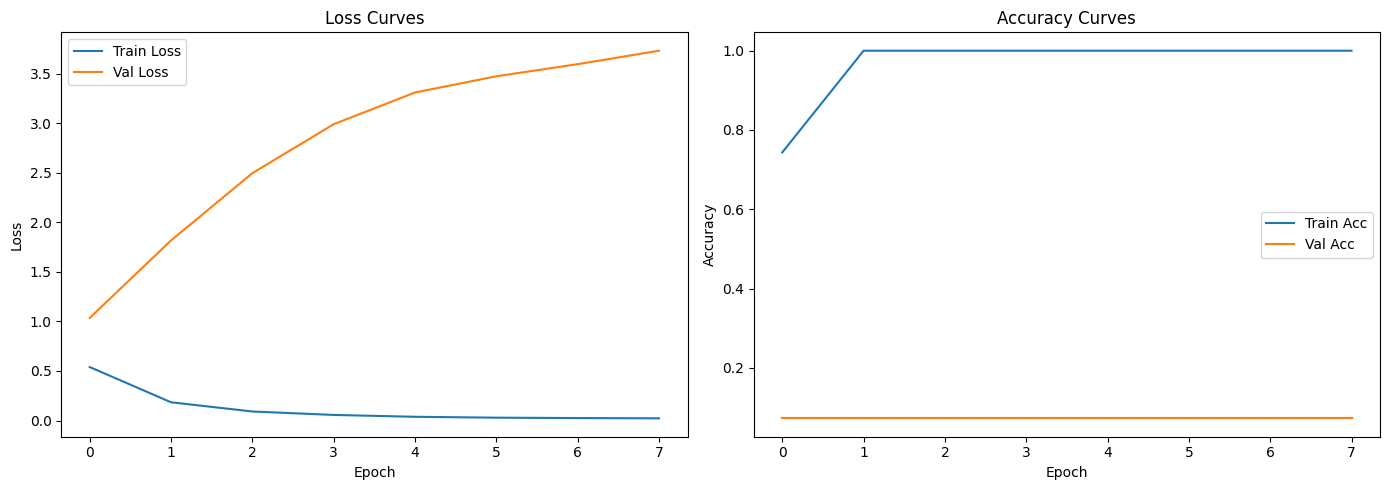

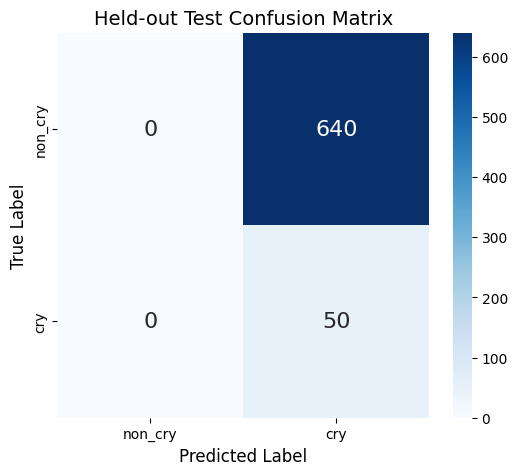


Classification Report:
              precision    recall  f1-score   support

     non_cry       0.00      0.00      0.00       640
         cry       0.07      1.00      0.14        50

    accuracy                           0.07       690
   macro avg       0.04      0.50      0.07       690
weighted avg       0.01      0.07      0.01       690



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss Curves"); ax1.legend()
ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy Curves"); ax2.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion matrix on held-out test set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
CLASS_NAMES = ["non_cry", "cry"]
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"size": 16})
plt.title("Held-out Test Confusion Matrix", fontsize=14)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.savefig("holdout_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## 8. Export ONNX Model

In [11]:
artifacts_dir = Path("/kaggle/working/artifacts")
artifacts_dir.mkdir(exist_ok=True)

model.eval()
dummy_input = torch.randn(1, 1, N_MELS, N_FRAMES).to(device)
onnx_path = artifacts_dir / "audio_model_fp32.onnx"

torch.onnx.export(
    model, dummy_input, str(onnx_path),
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
    opset_version=17,
)

# Save class labels
labels_path = artifacts_dir / "audio_labels.json"
labels_path.write_text(json.dumps(["noise", "cry"]))

# Copy training artifacts
shutil.copy2("training_curves.png", artifacts_dir / "training_curves.png")
shutil.copy2("holdout_confusion_matrix.png", artifacts_dir / "holdout_confusion_matrix.png")

print(f"ONNX export successful!")
print(f"  Model:  {onnx_path}")
print(f"  Labels: {labels_path}")
print(f"\nNext steps:")
print(f"  1. Download the 'artifacts' folder")
print(f"  2. Rename 'audio_model_fp32.onnx' -> 'audio_model.onnx'")
print(f"  3. Copy to data/models/ in the CPDS-AI project")
print(f"  4. Run: python3 main.py --mode evaluate")

/tmp/ipykernel_23/1239795707.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0930 06:25:04.316000 23 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0930 06:25:05.582000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, al

[torch.onnx] Obtain model graph for `AudioCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `AudioCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX export successful!
  Model:  /kaggle/working/artifacts/audio_model_fp32.onnx
  Labels: /kaggle/working/artifacts/audio_labels.json

Next steps:
  1. Download the 'artifacts' folder
  2. Rename 'audio_model_fp32.onnx' -> 'audio_model.onnx'
  3. Copy to data/models/ in the CPDS-AI project
  4. Run: python3 main.py --mode evaluate
